In [ ]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import warnings
import pandas as pd
import sys; sys.path.insert(0, '..')

from src.data_prep import (
    prepare_dataframe, ever_default_lifetime, plot_exclusion, lifetime_flag, drop_cols, odr_series
)

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)

In [4]:
# Import data
df = pd.read_parquet(
    '../data/raw/usedcar_transaction_score.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,MOB,del,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin,score_from_model,score_band
0,944370,A,N,1,507120.0,10,60.0,0,944370,6626063,...,0.0,0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1,944370,A,N,2,498668.0,10,60.0,0,944370,6626063,...,1.0,0,0.083333,0.0,0.000000,0.0,0.0,0.021251,582.0,B3
2,944370,A,N,2,490216.0,10,60.0,0,944370,6626063,...,2.0,0,0.168079,0.0,0.111111,0.0,0.0,0.021251,582.0,B3
3,944370,A,N,2,481764.0,10,60.0,0,944370,6626063,...,3.0,0,0.254310,0.0,0.222222,0.0,0.0,0.021251,582.0,B3
4,944370,A,N,2,473312.0,10,60.0,0,944370,6626063,...,4.0,0,0.342105,0.0,0.333333,0.0,0.0,0.021251,515.0,B4


In [5]:
# Constant parameters
ID_COL = 'Br_Con' #Primary key
PERIOD_COL = 'Monthkey' #Date key
DEFAULT_COL = 'del' #Default column
DEFAULT_FLAG = 4 #Any values greater than this value will be considered as default
DEFAULT_LAGS = 12
LIFETIME_LAGS = df['Monthkey'].max()

# ========================================== #
# Default definition is 90+ DPD in 12 months #
# ========================================== #

In [6]:
# Prepare dataset
steps = [
    ('Sorting and flag default', lambda d: prepare_dataframe(
        d, id_col = ID_COL, period_col = PERIOD_COL, default_col = DEFAULT_COL, default_flag = DEFAULT_FLAG
    )),
    ('Forward performance and ever default', lambda d: ever_default_lifetime(
        d, id_col = ID_COL, default_col = 'def', n_lags = DEFAULT_LAGS, lifetime_lags = LIFETIME_LAGS
    ))
]

for _, step_fn in steps:
    df = step_fn(df)

=== Processing ===
[Sort and create default flag]
=== Processing ===
[Forward performance windows and ever default]


In [7]:
# Exclusion criteria
"""
Rules:
    1. Bad at observation point
        - Defaulted transaction must be excluded.
        - Modeling the probability of performing to non-performing (Defaualt rate or Probability of Default; PD)
        - Any DPD greater than 90 DPD will be excluded.
    2. Less than 12 months forward performance window
        - Default definition is 90+ DPD in 12 months meaning the last 12 months are invalid.
        - Any transactions of last 12 months are excluded from development samaple. 
    3. Last transaction
        - No probability to observed
        - Any transactions have no next month are excluded from development samaple. 
"""

# Keep log records and exclusion
excluded_logs = [['Original', len(df), 0]] #Original transaction
excluded_steps = {
    "Existing default": "`def` != 1",
    "Last 12 months performance": "Monthkey <= @LIFETIME_LAGS - 12",
    "Last transaction": "def1.notnull()"
}

# Exclusion
print("=== Processing ===\n[Exclusion]")
n_steps = len(excluded_steps) #Total exclusion steps

for i, (step, criteria) in enumerate(excluded_steps.items(), start = 1):
    n_before = len(df)
    df = df.query(criteria)
    n_after = len(df)
    print(f"[✓] {step:<30}: {n_before - n_after:<6} transactions")
    excluded_logs.append([step, n_before, n_after])
    is_last = (i == n_steps)
    if is_last:
        excluded_logs.append(['Final', n_after, 0])

=== Processing ===
[Exclusion]
[✓] Existing default              : 7670   transactions
[✓] Last 12 months performance    : 188629 transactions
[✓] Last transaction              : 4729   transactions


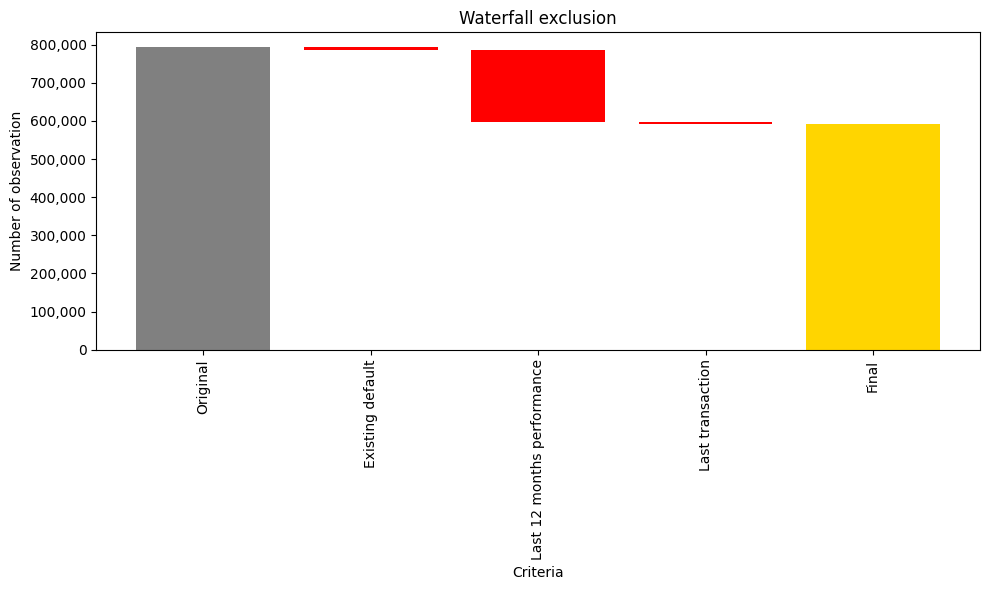

In [8]:
# Plot waterfall summary
plot_exclusion(excluded_logs)

In [9]:
# Lifetime flag
df = lifetime_flag(df, default_col = 'def', lifetime_lags = LIFETIME_LAGS)
df = drop_cols(df, default_col = 'def', lifetime_lags = LIFETIME_LAGS)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin,score_from_model,score_band,def,ever_default_12,lifetime_flag,times
13915,A-A829614,A,N,1,992664.0,10,72.0,0,2416423,5543426,...,0.000000,NaN,NaN,NaN,NaN,NaN,0,0,1,41
13916,A-A829614,A,N,2,978877.0,10,72.0,0,2416423,5543426,...,0.000000,0.000000,0.0,0.018681,526.0,B4,0,0,1,40
13917,A-A829614,A,N,1,978877.0,21,72.0,26,2416423,5543426,...,0.055556,0.000000,0.0,0.018681,526.0,B4,0,0,1,39
13918,A-A829614,A,N,1,978877.0,41,72.0,56,2416423,5543426,...,0.037037,0.018681,1.0,0.018681,277.0,B6,0,0,1,38
13919,A-A829614,A,N,2,951303.0,41,72.0,26,2416423,5543426,...,0.055556,0.037362,2.0,0.018681,226.0,B6,0,0,1,37


In [10]:
# ODR Calculation --> For forward-looking model (later)
odr_series(df, period_col = 'AS_OF_DATE', default_col = 'ever_default_12')

=== Processing ===
[ODR Calculation]
=== Result ===
[Export location: '..data/processed/odr.parquet']


In [11]:
# Export
df.to_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)